In [3]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
def make_lead(a=1, t=1.0, W=10):
    lat = kwant.lattice.square(a, norbs=1)
    sym_lead = kwant.TranslationalSymmetry((-a, 0))
    lead = kwant.Builder(sym_lead)
    
    for j in range(W):
        lead[lat(0, j)] = 4 * t
        if j > 0:
            lead[lat(0, j), lat(0, j-1)] = -t
        lead[lat(1, j), lat(0, j)] = -t
    
    return lead

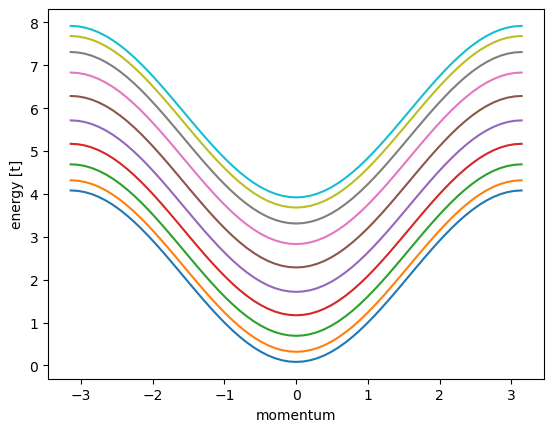

In [4]:
lead = make_lead().finalized()
kwant.plotter.bands(lead, show=False)
plt.xlabel("momentum")
plt.ylabel("energy [t]")
plt.show()

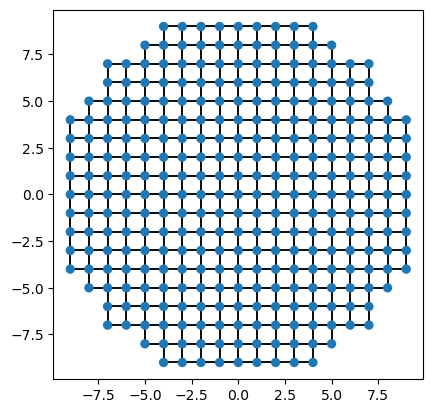

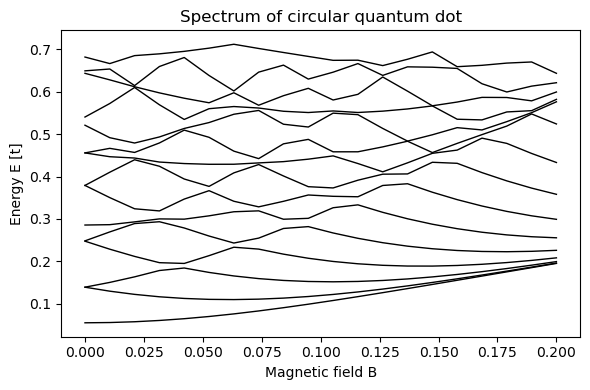

In [15]:
import kwant
import numpy as np
import matplotlib.pyplot as pyplot
from scipy.sparse.linalg import eigsh as sla
from cmath import exp   # 关键：Peierls 相位

def make_system(a=1, t=1.0, r=10):
    lat = kwant.lattice.square(a, norbs=1)
    syst = kwant.Builder()

    # Define the quantum dot
    def circle(pos):
        x, y = pos
        return x**2 + y**2 < r**2

    # Peierls phase in Landau gauge A = (-By, 0)
    def hopx(site1, site2, B):
        y = site1.pos[1]
        return -t * exp(-1j * B * y)

    syst[lat.shape(circle, (0, 0))] = 4 * t
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hopx
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = -t

    return syst.finalized()


def plot_spectrum(syst, Bfields):
    energies = []

    for B in Bfields:
        ham_mat = syst.hamiltonian_submatrix(
            params=dict(B=B), sparse=True
        )
        ev = sla(
            ham_mat.tocsc(),
            k=15,
            sigma=0,
            return_eigenvectors=False
        )
        energies.append(np.sort(ev))

    energies = np.array(energies)

    pyplot.figure(figsize=(6, 4))
    for n in range(energies.shape[1]):
        pyplot.plot(Bfields, energies[:, n], 'k-', lw=1)

    pyplot.xlabel("Magnetic field B")
    pyplot.ylabel("Energy E [t]")
    pyplot.title("Spectrum of circular quantum dot")
    pyplot.tight_layout()
    pyplot.show()


# ======================
# 运行
# ======================
kwant.plot(syst)
syst = make_system(r=10)
Bfields = np.linspace(0, 0.2, 20)
plot_spectrum(syst, Bfields)


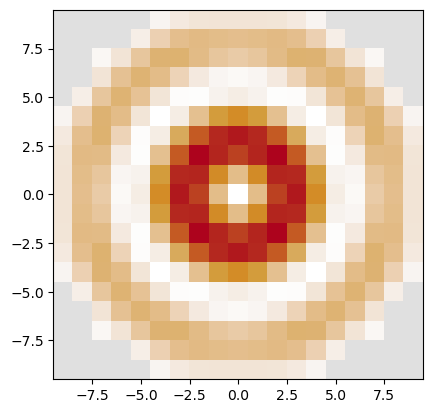

In [21]:
from scipy.sparse.linalg import eigsh
def plot_wave_function(syst, B=0.001, n=9):
    ham_mat = syst.hamiltonian_submatrix(
        sparse=True, params=dict(B=B)
    )

    evals, evecs = eigsh(
        ham_mat.tocsc(), k=20, sigma=0
    )

    idx = np.argsort(evals)
    evecs = evecs[:, idx]

    kwant.plotter.map(
        syst,
        np.abs(evecs[:, n])**2,
        colorbar=False,
        oversampling=1
    )

plot_wave_function(syst, B=0.001)


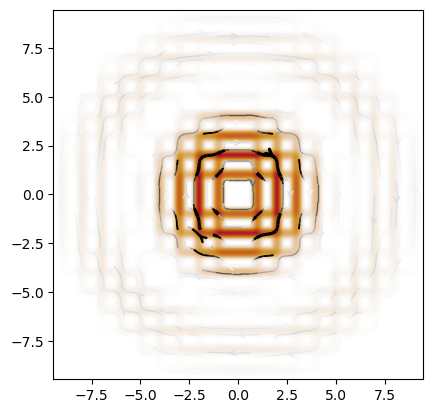

In [29]:
import scipy.sparse.linalg as sla
def plot_current(syst, B=0.001):
    # Calculate the wave functions in the system.
    ham_mat = syst.hamiltonian_submatrix(sparse=True, params=dict(B=B))
    evals, evecs = sorted_eigs(sla.eigsh(ham_mat.tocsc(), k=20, sigma=0))

    # Calculate and plot the local current of the 10th eigenmode.
    J = kwant.operator.Current(syst)
    current = J(evecs[:, 9], params=dict(B=B))
    kwant.plotter.current(syst, current, colorbar=False)
plot_current(syst, B=0.001)